In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import DATA_PROCESSED, SENSOR_NAMES

train = pd.read_parquet(DATA_PROCESSED / "train_FD001.parquet")
train = train.rename(columns=SENSOR_NAMES)
sensors = list(SENSOR_NAMES.values())
train.shape, train["unit"].nunique()

((20631, 27), 100)

# EDA FD001: sensor selection and healthy-window choice

## sensor selection

In [2]:
stats = train[sensors].agg(["mean", "std", "min", "max"]).T
stats["cv"] = stats["std"] / stats["mean"].abs()  # coefficient of variation
stats["n_unique"] = train[sensors].nunique()
stats.sort_values("std")

,mean,std,min,max,cv,n_unique
T2,518.670000,0.000000e+00,518.6700,518.6700,0.000000e+00,1
epr,1.300000,0.000000e+00,1.3000,1.3000,0.000000e+00,1
PCNfR_dmd,100.000000,0.000000e+00,100.0000,100.0000,0.000000e+00,1
Nf_dmd,2388.000000,0.000000e+00,2388.0000,2388.0000,0.000000e+00,1
farB,0.030000,3.469531e-18,0.0300,0.0300,1.156510e-16,1
P2,14.620000,5.329200e-15,14.6200,14.6200,3.645143e-16,1
P15,21.609803,1.388985e-03,21.6000,21.6100,6.427569e-05,2
BPR,8.442146,3.750504e-02,8.3249,8.5848,4.442595e-03,1918
Nf,2388.096652,7.098548e-02,2387.9000,2388.5600,2.972471e-05,53
NRf,2388.096152,7.191892e-02,2387.8800,2388.5600,3.011559e-05,56


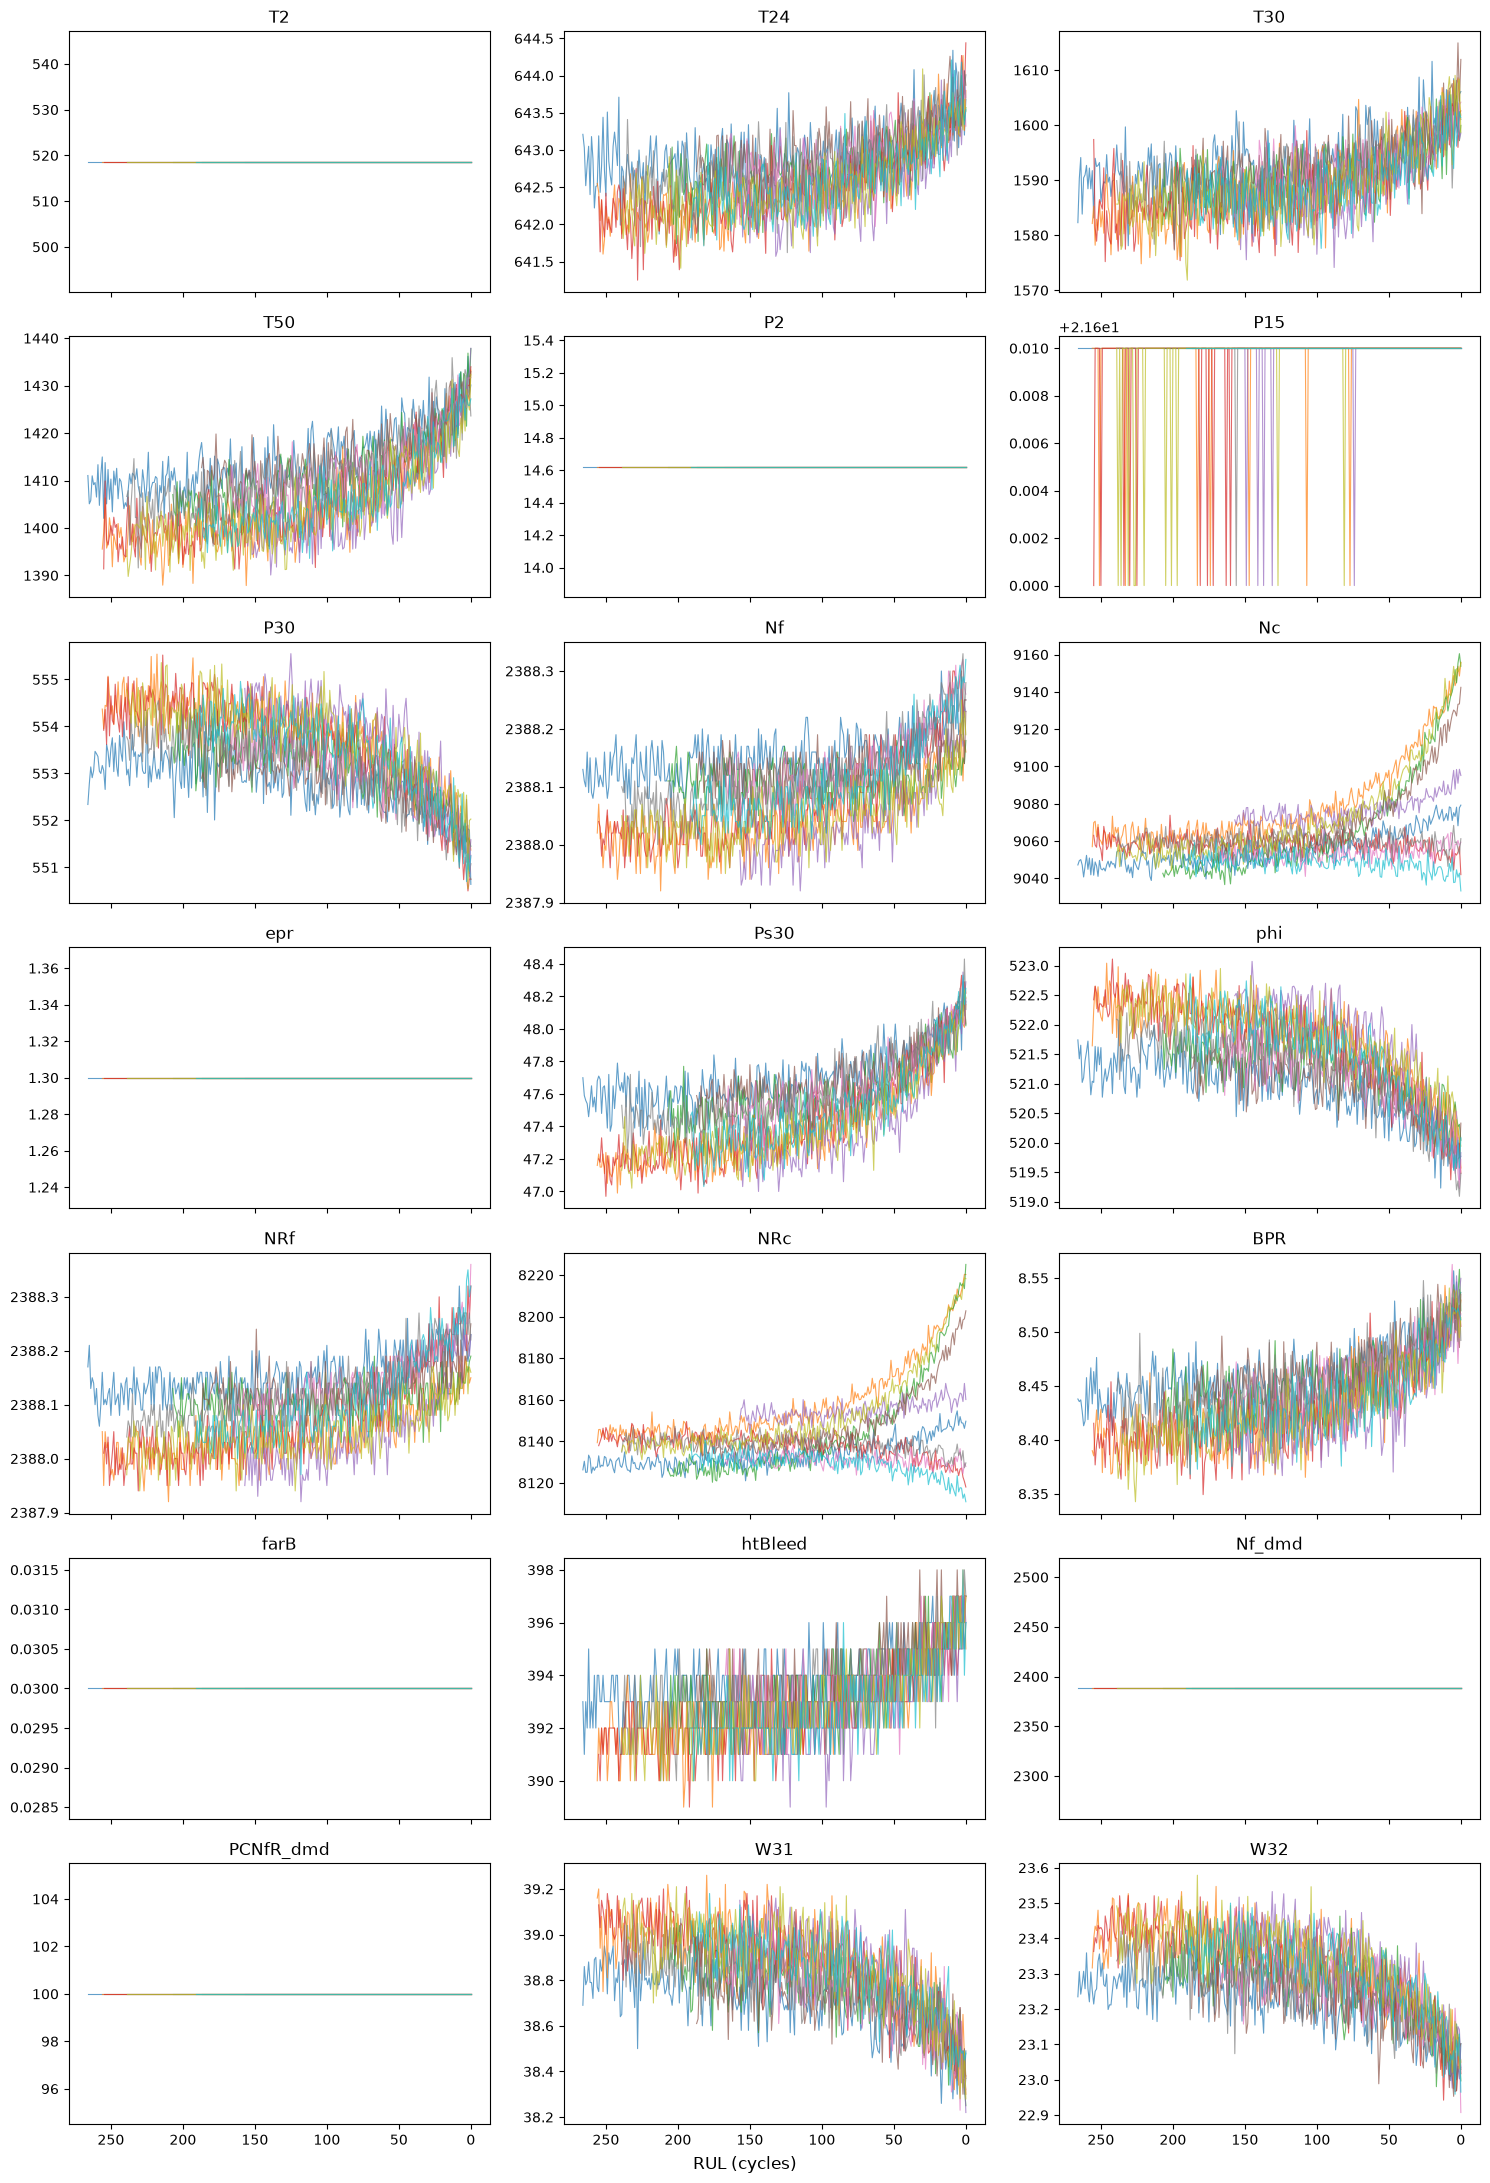

In [3]:
units = train["unit"].drop_duplicates().sample(10, random_state=42)
fig, axes = plt.subplots(7, 3, figsize=(15, 22), sharex=True)
for ax, s in zip(axes.flat, sensors, strict=True):
    for u in units:
        d = train[train["unit"] == u]
        ax.plot(d["rul"], d[s], lw=0.8, alpha=0.7)
    ax.set_title(s)
    ax.invert_xaxis()
fig.supxlabel("RUL (cycles)")
plt.tight_layout()

In [4]:
# T24, T30, T50, P30, Nf, Nc, Ps30, phi, NRf, NRc, BPR, htBleed, W31, W32

from src.config import FEATURE_SENSORS

keep = FEATURE_SENSORS

# Sensor–RUL Spearman correlation for each motor
rho = train.groupby("unit")[["rul"] + keep].apply(
    lambda d: d[keep].corrwith(d["rul"], method="spearman")
)
pd.DataFrame({"median_rho": rho.median(), "share_neg": (rho < 0).mean()}).round(2).sort_values(
    "median_rho"
)

,median_rho,share_neg
Ps30,-0.82,1.00
T50,-0.78,1.00
Nf,-0.77,1.00
NRf,-0.76,1.00
Nc,-0.74,0.71
BPR,-0.72,1.00
T24,-0.67,1.00
NRc,-0.66,0.60
htBleed,-0.66,1.00
T30,-0.64,1.00


In [5]:
# Average deviation normalized to a common direction, in 25-cycle RUL segments
z = (train[keep] - train[keep].mean()) / train[keep].std()
direction = -rho.median().apply(lambda r: 1 if r > 0 else -1)  # toward the failure = up
score = (z * direction).mean(axis=1)
bucket = train["rul"].clip(upper=300) // 25 * 25
score.groupby(bucket).mean().round(2)

rul
0      1.47
25     0.63
50     0.15
75    -0.14
100   -0.32
125   -0.45
150   -0.52
175   -0.59
200   -0.67
225   -0.68
250   -0.69
275   -0.73
300   -0.69
dtype: float64

## healthy-window choice

Objective: To define the “healthy” data that will be used to train anomaly models.
- **A:** The first N cycles of each engine (the only information known in the field is the engine’s entry into service)
- **B:** Cycles in the training set where RUL > R (requires knowledge of the failure time)

RUL is used here solely to **measure** the extent of degradation in the options, not to select data.

In [6]:
life = train.groupby("unit")["cycle"].max()
life.describe().round(1)

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64

In [7]:
EARLY_RUL = 125  # only to measure contamination, never to select data


def summarize(name, window):
    per_unit = window.groupby("unit").size()
    late = window[window["rul"] < EARLY_RUL]
    return {
        "option": name,
        "rows": len(window),
        "units": window["unit"].nunique(),
        "rows/unit min": per_unit.min(),
        "rows/unit median": int(per_unit.median()),
        "rows/unit max": per_unit.max(),
        f"% rows RUL<{EARLY_RUL}": round(100 * len(late) / len(window), 1),
        f"units with RUL<{EARLY_RUL}": late["unit"].nunique(),
        "min RUL in window": window["rul"].min(),
    }


rows = [summarize(f"A: first {n} cycles", train[train["cycle"] <= n]) for n in (20, 30, 50)]
rows += [summarize(f"B: RUL > {r}", train[train["rul"] > r]) for r in (125, 150)]
pd.DataFrame(rows).set_index("option")

,rows,units,rows/unit min,rows/unit median,rows/unit max,% rows RUL<125,units with RUL<125,min RUL in window
option,,,,,,,,
A: first 20 cycles,2000,100,20,20,20,2.1,4,108
A: first 30 cycles,3000,100,30,30,30,3.6,10,98
A: first 50 cycles,5000,100,50,50,50,9.6,25,78
B: RUL > 125,8031,100,2,73,236,0.0,0,126
B: RUL > 150,5607,93,2,49,211,0.0,0,151


**Decision: A, N = 30** (`HEALTHY_CYCLES` in `src/config.py`)

- Deployment-realistic: RUL and downtime are not used.
- Equal data from each motor (30 rows); in B, 2–236 rows per motor, giving more weight to motors with longer lifespans.
- Trade-off: 3.6% of the rows are in the RUL < 125 region (10 engines, worst RUL 98) → the threshold rises slightly, and the alarm may be delayed.
- Sensitivity analysis: Will also be reported for N = 20 and 50.

In [8]:
from src.config import HEALTHY_CYCLES

healthy = train[train["cycle"] <= HEALTHY_CYCLES]
len(healthy), healthy["unit"].nunique(), (healthy["rul"] < 125).mean()

(3000, 100, np.float64(0.036))